# Step 4 — Project the 11 ST clusters onto METABRIC

Runs the Seurat anchor-based transfer of the TCGA 11 ST-cluster labels onto the
METABRIC cohort, then aggregates per-domain predictions into per-patient cluster
proportions and renders Figure S7A.

**Stages in this notebook**

1. **Run the transfer** (R, Seurat). Invokes `../lib/transfer_TCGA_to_external.R`
   via `subprocess`. This requires R + Seurat on the host, plus the upstream
   TCGA reference Seurat object and the METABRIC query Seurat object — both
   are large `.qs` files held on Biowulf and not committed here. The call is
   commented out by default; the resulting per-domain CSV is already shipped
   under `data/best_clust.csv` (derived from `clusters_reviewer_3/best_clust.RDS`).
2. **Aggregate** per-domain predictions to a per-patient × per-cluster proportion
   matrix.
3. **Render** the cluster-by-patient heatmap (rows = the 11 clusters in the
   paper order, columns = patients grouped by their projected SpatioType).

## Setup

In [1]:
import sys
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from clustering_helpers import (
    SPATIOTYPE_PALETTE, HEATMAP_ROW_ORDER,
)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Stage 1 — Run the Seurat anchor-based projection (R)

The transfer is performed by [`../lib/transfer_TCGA_to_external.R`](../lib/transfer_TCGA_to_external.R).
Core of the script (one tuned parameter set, lifted from
`spatial_clusters/3_transfer_check_param_METABRIC.r`):

```r
anchors <- FindTransferAnchors(
  reference = target, query = query,
  dims = 1:30, reduction = "pcaproject",
  k.anchor = 5, k.score = 30, k.filter = 200, l2.norm = TRUE
)
preds <- TransferData(
  anchorset = anchors,
  refdata = target@meta.data$mapped_clusters,
  weight.reduction = "pcaproject", k.weight = 50
)
```

To re-run the projection, uncomment the `subprocess` call below. The upstream
inputs (`.qs` files for the TCGA reference and METABRIC query) live on Biowulf
and are not committed. The per-domain prediction CSV is shipped pre-computed
as `../data/best_clust.csv`.

In [2]:
import subprocess

REFERENCE_QS = "/vf/users/Ruppin_ST/scr/new_tras_clusters/tcga_target_seurat_best_genes.qs"
QUERY_QS     = "/vf/users/Ruppin_ST/Cell_revisions/spatial_clusters/METABRIC_seurat.qs"
OUT_CSV      = "../data/best_clust.csv"

# Uncomment to re-run (requires R + Seurat + access to the .qs files above):
# subprocess.run(["Rscript", "../lib/transfer_TCGA_to_external.R",
#                 REFERENCE_QS, QUERY_QS, OUT_CSV],
#                check=True)

per_domain = pd.read_csv(OUT_CSV)
per_domain.head()

,domain_id,slide_name,proportion_of_spots,predicted_cluster,prediction_score
0,1_#_MB-7155,MB-7155,0.189725,Cluster_4,NaN
1,2_#_MB-7155,MB-7155,0.183113,Cluster_10,NaN
2,3_#_MB-7155,MB-7155,0.165310,Cluster_7,NaN
3,0_#_MB-7155,MB-7155,0.155646,Cluster_7,NaN
4,4_#_MB-7155,MB-7155,0.116989,Cluster_10,NaN


## Stage 2 — Aggregate per-domain predictions to per-patient cluster proportions

For each patient (`slide_name`), sum `proportion_of_spots` across domains within
each predicted cluster.

In [3]:
cluster_cols = [f"Cluster_{i}" for i in range(1, 12)]

wide = (per_domain
        .groupby(["slide_name", "predicted_cluster"])["proportion_of_spots"]
        .sum().unstack(fill_value=0))
wide = wide.reindex(columns=cluster_cols, fill_value=0)
wide.index.name = "slide_name"
wide.head()

predicted_cluster,Cluster_1,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_8,Cluster_9,Cluster_10,Cluster_11
slide_name,,,,,,,,,,,
MB-0008,0,0.0,0,0.0,0,0.177880,0.128111,0,0.000000,0.694009,0
MB-0050,0,0.0,0,0.0,0,0.319728,0.000000,0,0.000000,0.680272,0
MB-0060,0,0.0,0,0.0,0,0.000000,0.358285,0,0.239826,0.401890,0
MB-0102,0,0.0,0,0.0,0,0.209350,0.162602,0,0.000000,0.628049,0
MB-0106,0,0.0,0,0.0,0,0.273782,0.000000,0,0.000000,0.726218,0


## Stage 3 — Heatmap

Same rendering as the TCGA heatmap in notebook 03: rows = 11 clusters in the
paper-frozen order, columns = patients grouped by SpatioType. The SpatioType
labels come from notebook 05 (Aitchison projection); the small label file
`metabric_spatiotypes.csv` is also pre-computed and committed.

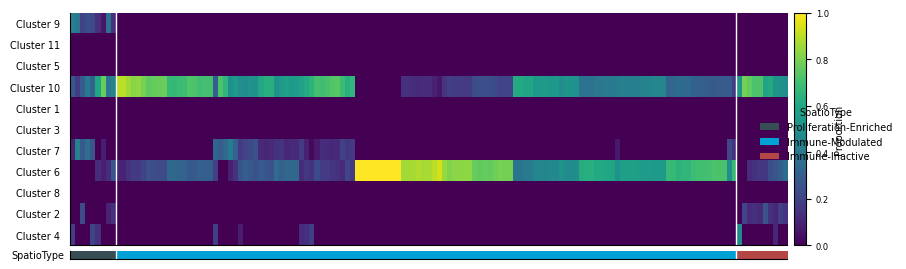

In [4]:
sp = pd.read_csv("../data/metabric_spatiotypes.csv", index_col=0)
df_h = wide.join(sp[["SpatioType"]], how="inner")

# Rename Cluster_<n> → "Cluster <n>" to match HEATMAP_ROW_ORDER
df_h = df_h.rename(columns={f"Cluster_{i}": f"Cluster {i}" for i in range(1, 12)})
df_h["SpatioType"] = df_h["SpatioType"].replace({"Proliferative": "Proliferation-Enriched"})

main_st = ["Proliferation-Enriched", "Immune-Modulated", "Immune-Inactive"]

# Order columns: by SpatioType block, then Ward order within block
from scipy.cluster.hierarchy import linkage, leaves_list

ordered = []
for st in main_st:
    block = df_h.index[df_h["SpatioType"] == st]
    if len(block) > 1:
        sub_mat = df_h.loc[block, HEATMAP_ROW_ORDER].values
        block = block[leaves_list(linkage(sub_mat, method="ward"))]
    ordered.extend(block)

heat   = df_h.loc[ordered, HEATMAP_ROW_ORDER].T.values
col_st = df_h.loc[ordered, "SpatioType"].values

# Block boundaries
boundaries = []
prev = col_st[0]
for i, s in enumerate(col_st):
    if s != prev:
        boundaries.append(i); prev = s

fig = plt.figure(figsize=(9.5, 3.2))
gs = gridspec.GridSpec(2, 2, figure=fig,
                       width_ratios=[60, 1], height_ratios=[30, 1],
                       hspace=0.05, wspace=0.02)

ax_h = fig.add_subplot(gs[0, 0])
im = ax_h.imshow(heat, aspect="auto", cmap="viridis", interpolation="nearest", vmin=0, vmax=1)
for b in boundaries:
    ax_h.axvline(b - 0.5, color="white", linewidth=1.0)
ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
ax_h.set_xticks([]); ax_h.tick_params(left=False)

ax_cb = fig.add_subplot(gs[0, 1])
plt.colorbar(im, cax=ax_cb).set_label("Proportion", fontsize=7)
ax_cb.tick_params(labelsize=6)

ax_a = fig.add_subplot(gs[1, 0], sharex=ax_h)
rgb = np.array([list(mcolors.to_rgb(SPATIOTYPE_PALETTE[s])) for s in col_st])[None, :, :]
ax_a.imshow(rgb, aspect="auto", interpolation="nearest")
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_ylabel("SpatioType", rotation=0, ha="right", va="center", fontsize=7)
for b in boundaries:
    ax_a.axvline(b - 0.5, color="white", linewidth=1.0)

handles = [mpatches.Patch(facecolor=SPATIOTYPE_PALETTE[s], label=s) for s in main_st]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.0, 0.5),
           fontsize=7, frameon=False, title="SpatioType", title_fontsize=7)
plt.show()